In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os



In [ ]:
dir = r"C:\Users\hwilson23\Documents\GitHub\collagen_3D_multimetric-main"
filelist = [f for f in os.listdir(dir) if "final_dataframe_byslice_pos_" in f]
all_frames = []
for t in filelist:
    df = pd.read_csv(os.path.join(dir, t))
    df = df.drop(['TotalImageArea','z_depth','distance3d','neighbor3d','bin_num3d','roi','type'], axis=1, errors='ignore')
    df['concentration'] = df['image_name'].str.extract(r"(\d+mgml)")

    if 'position' not in df.columns:
        pos_match = re.search(r'pos_(\d+)', t, flags=re.IGNORECASE)
        df['position'] = int(pos_match.group(1)) if pos_match is not None else np.nan

    all_frames.append(df)

combined = pd.concat(all_frames, ignore_index=True)
combined['position'] = combined['position'].astype('Int64')

# Aggregate across slices for each position/timepoint
group_cols = ['position', 'timepoint']
grouped = combined.groupby(group_cols).mean(numeric_only=True).reset_index()

numeric_cols = grouped.select_dtypes(include=[np.number]).columns	
exclude_cols = ['slice', 'timepoint', 'position']
plot_cols = [col for col in numeric_cols if col not in exclude_cols]

for col in plot_cols:
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=grouped, x='timepoint', y=col, hue='position', marker='o', palette='tab10')
    plt.title(f"Mean {col} over time by position")
    plt.xlabel('Timepoint')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.legend(title='Position', bbox_to_anchor=(1.04, 1), borderaxespad=0)
    plt.tight_layout()
    plt.show()

SyntaxError: invalid syntax (4003665448.py, line 22)

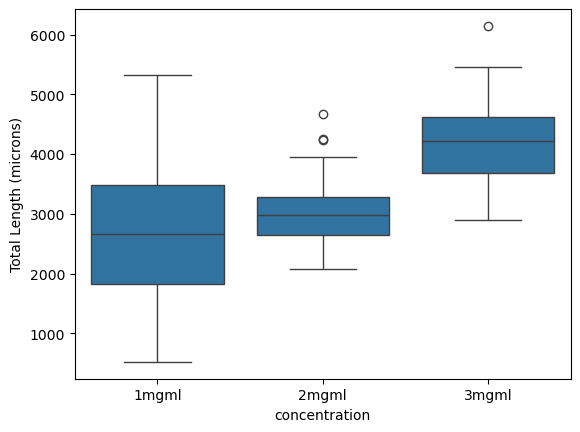

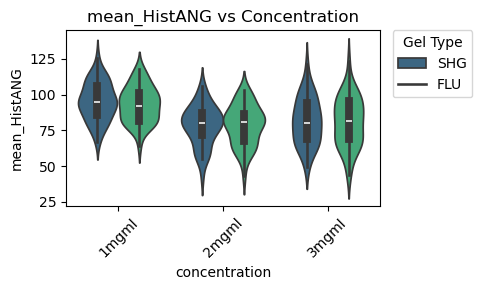

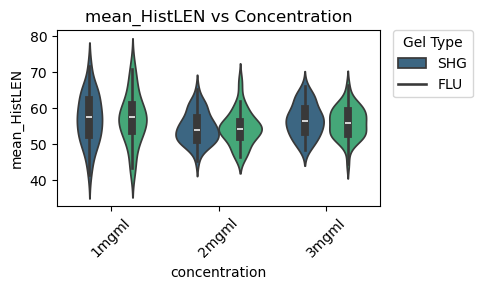

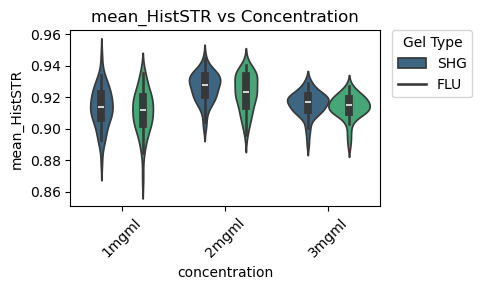

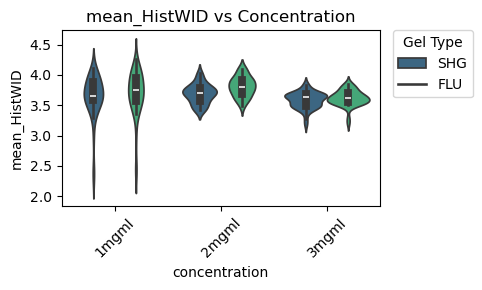

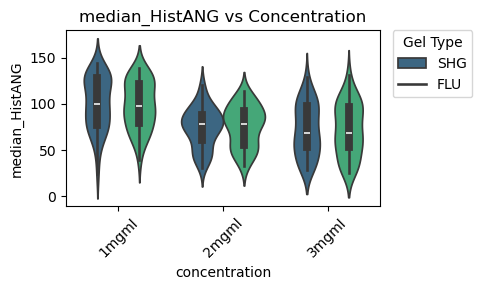

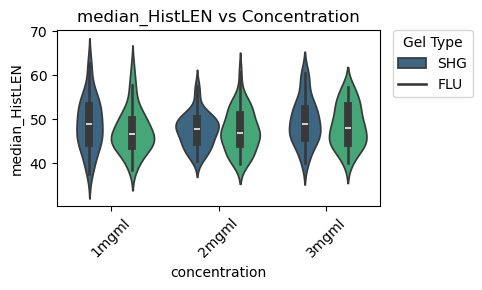

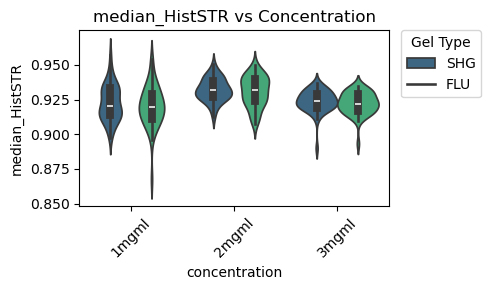

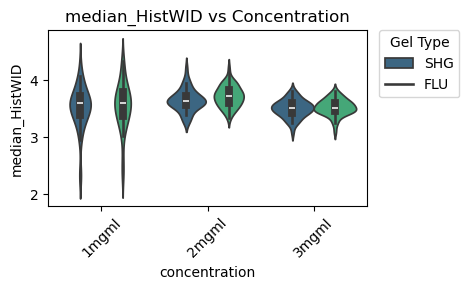

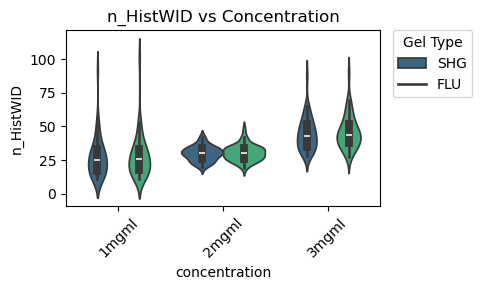

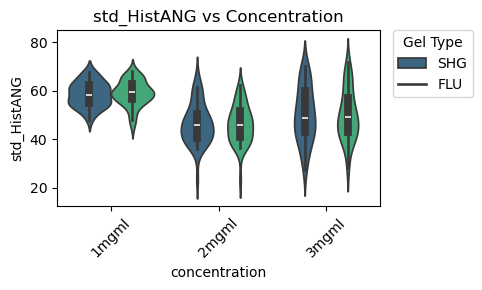

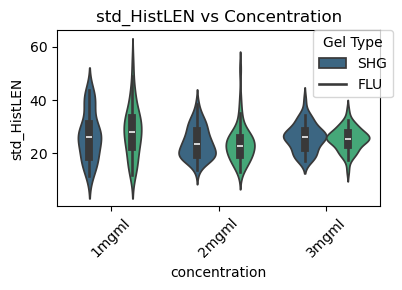

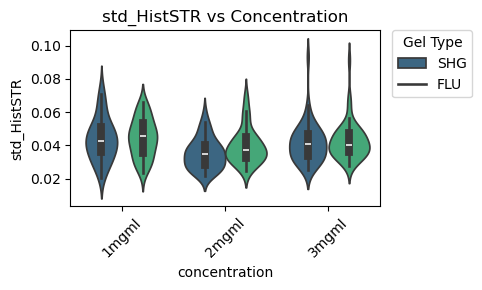

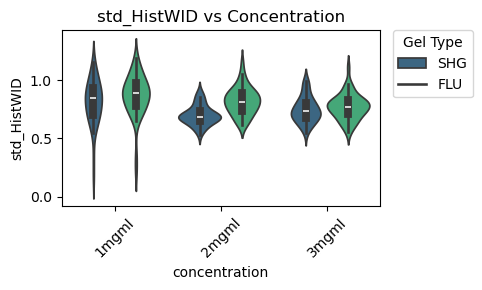

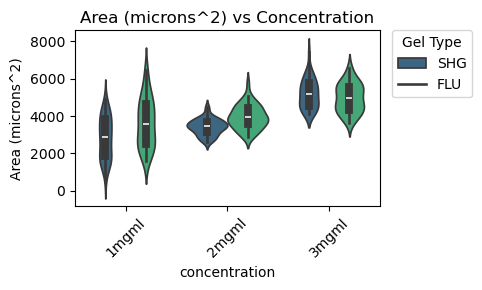

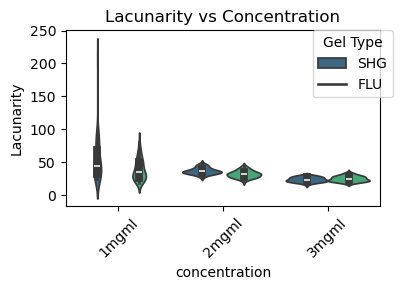

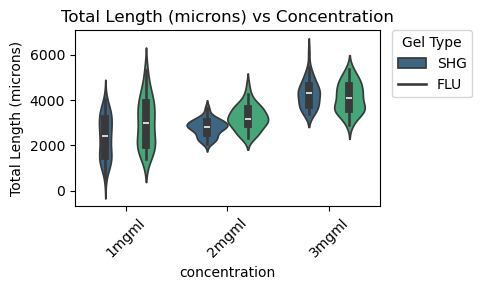

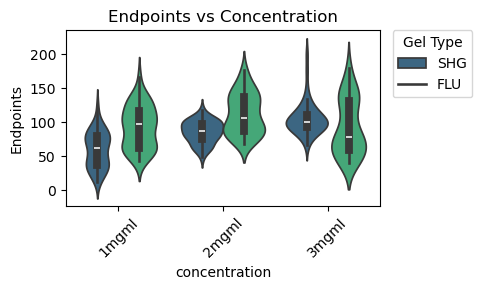

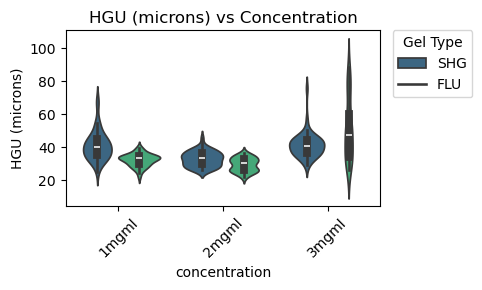

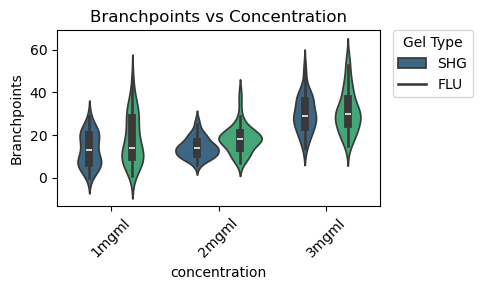

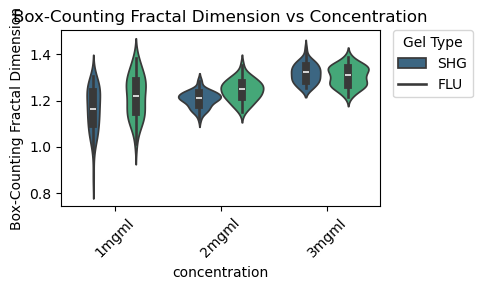

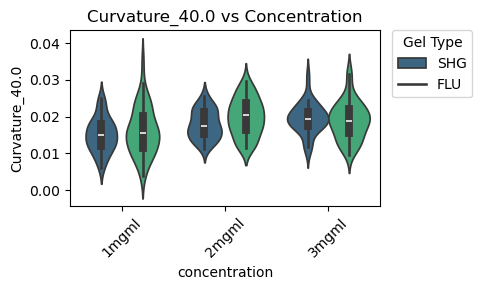

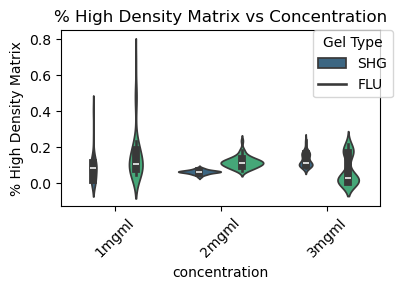

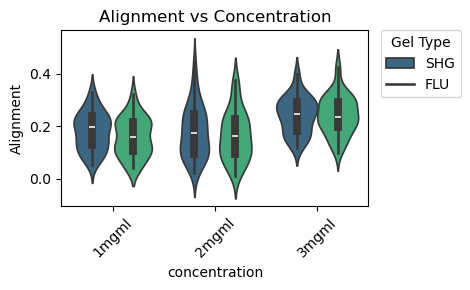

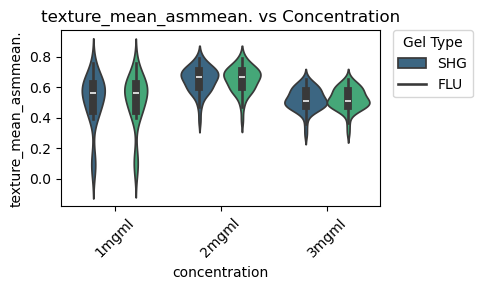

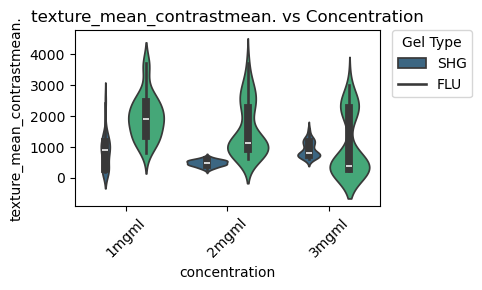

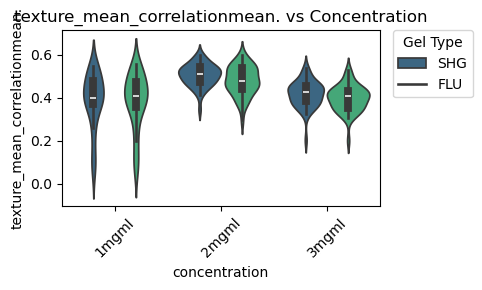

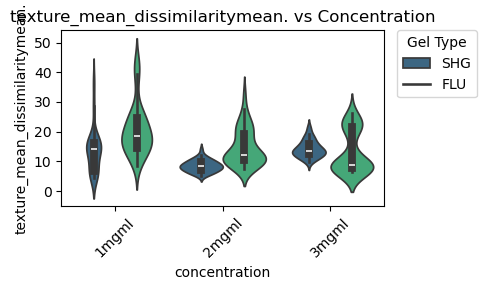

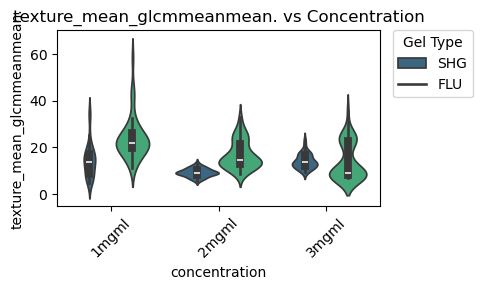

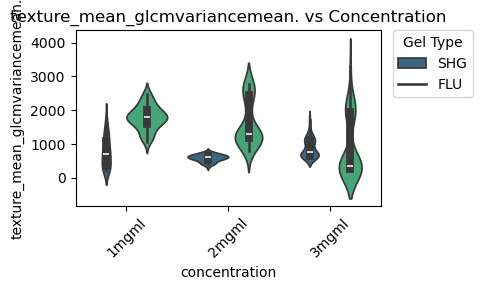

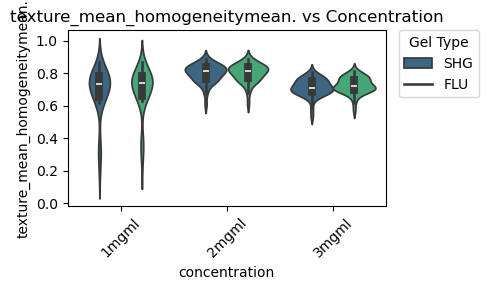

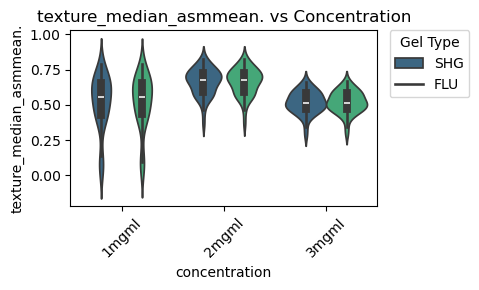

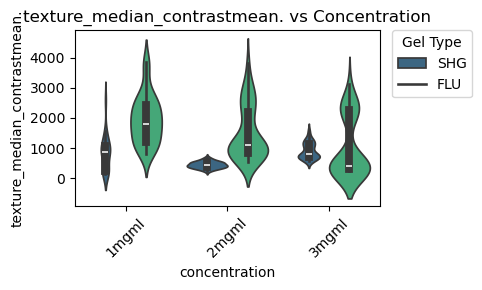

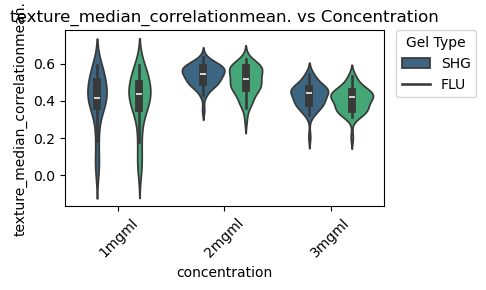

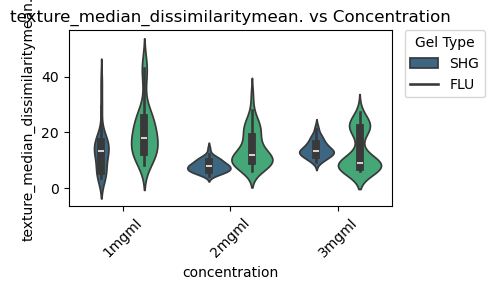

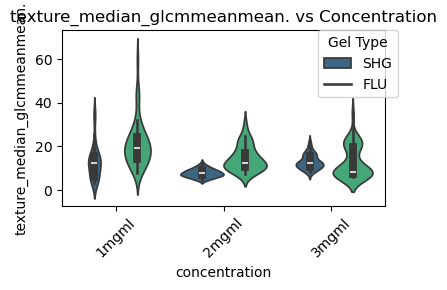

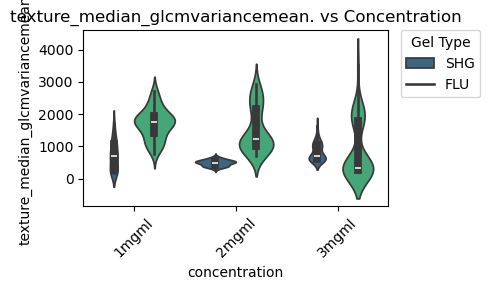

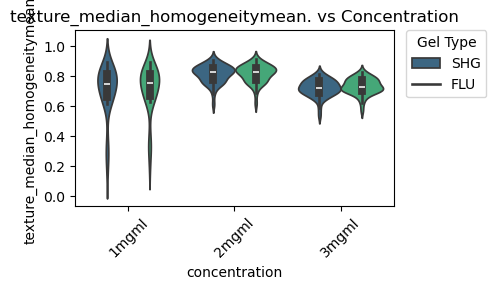

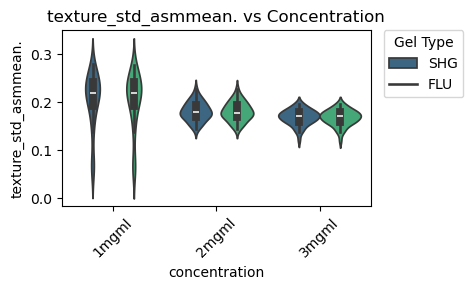

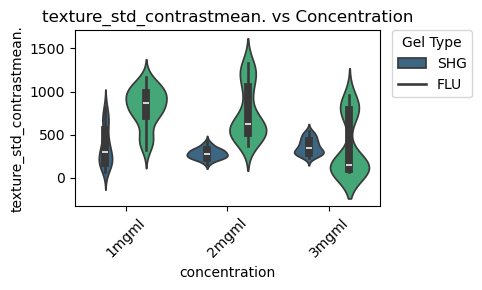

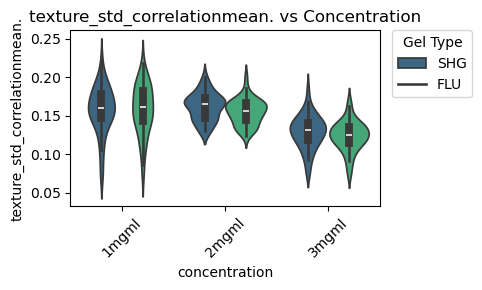

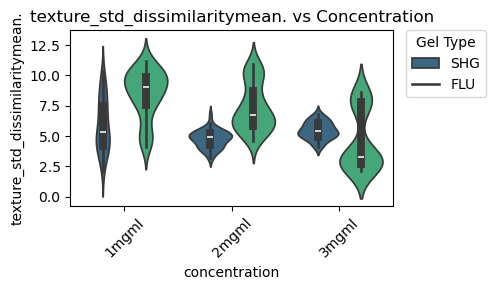

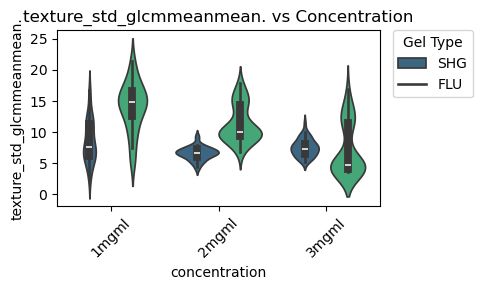

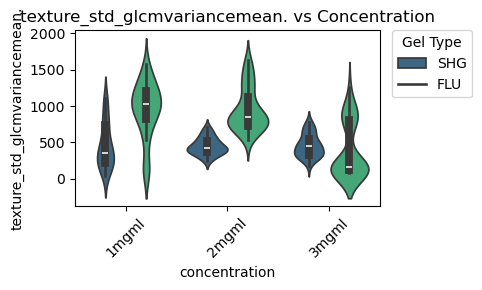

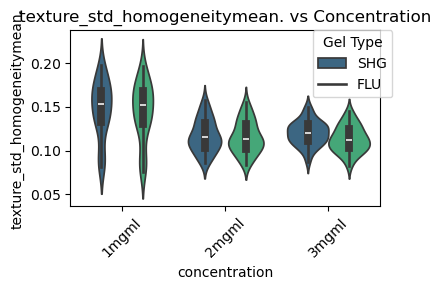

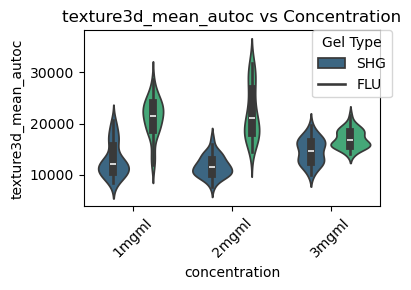

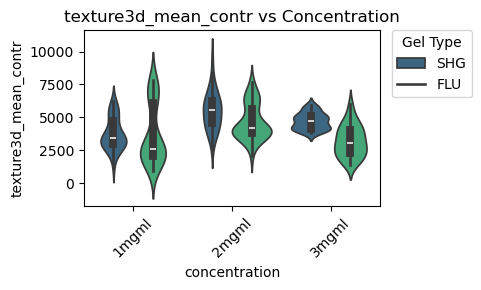

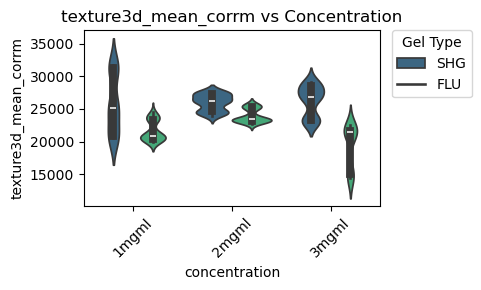

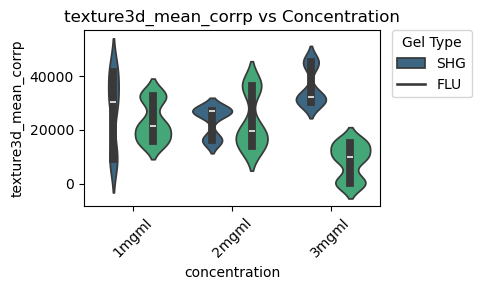

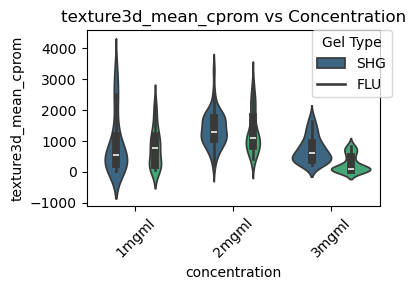

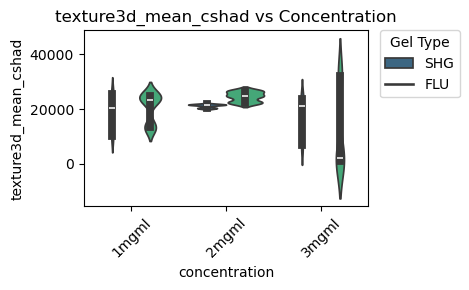

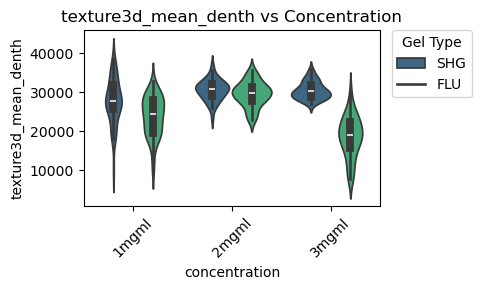

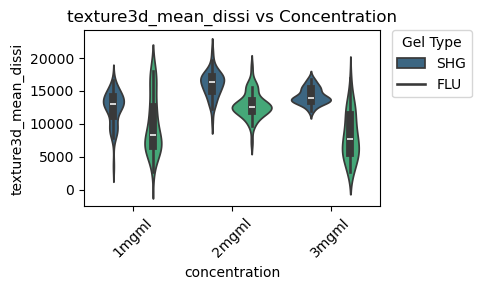

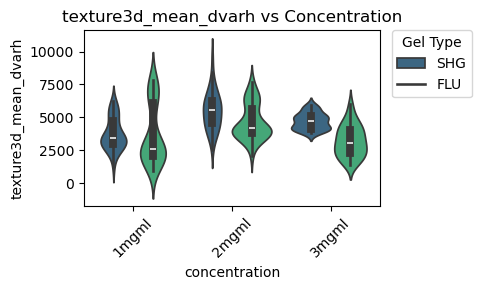

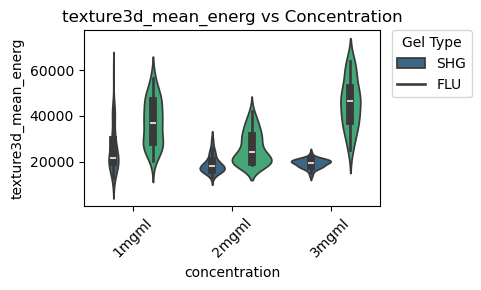

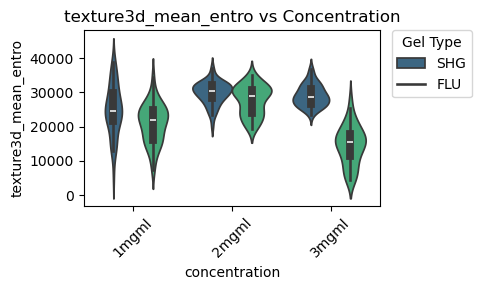

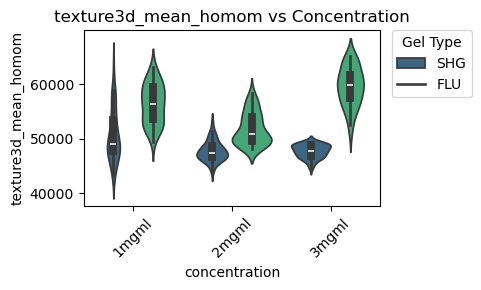

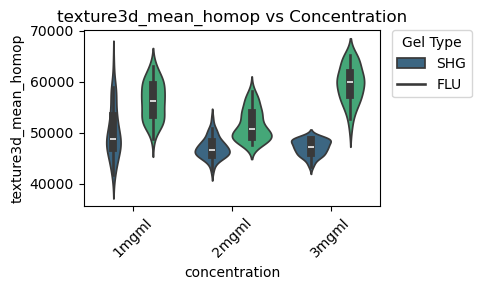

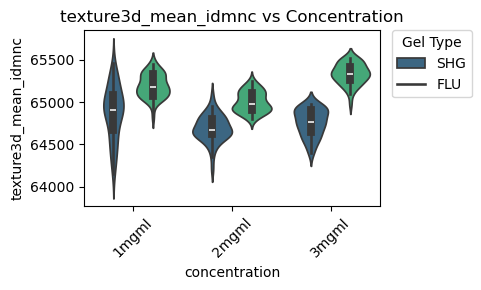

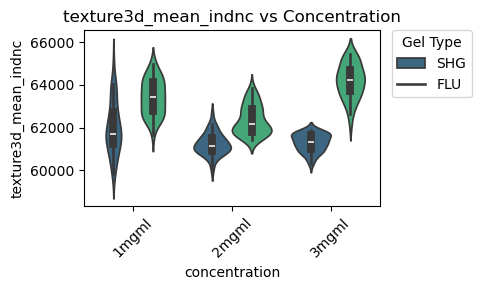

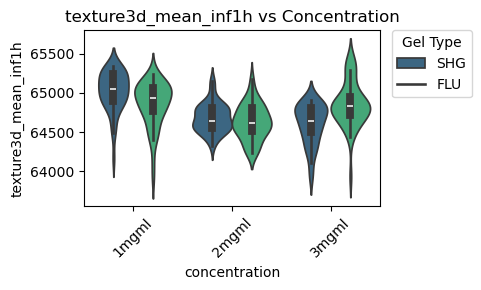

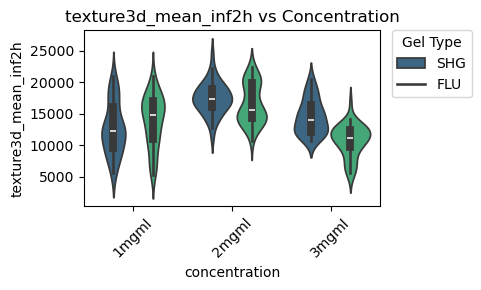

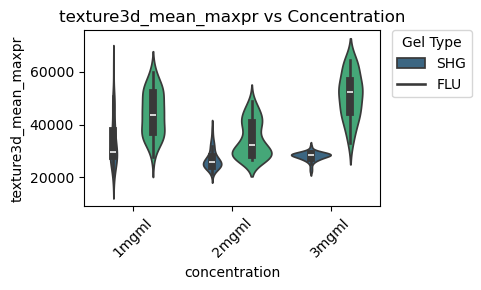

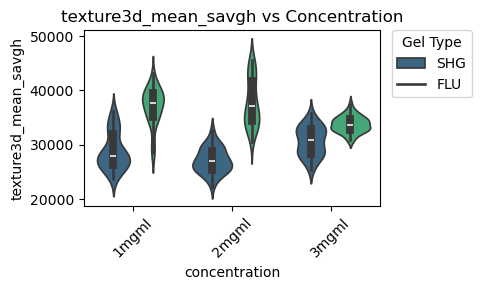

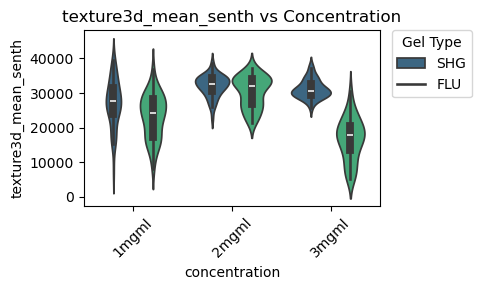

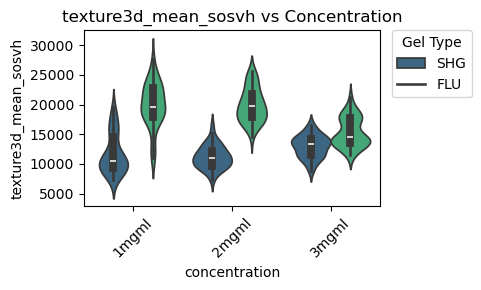

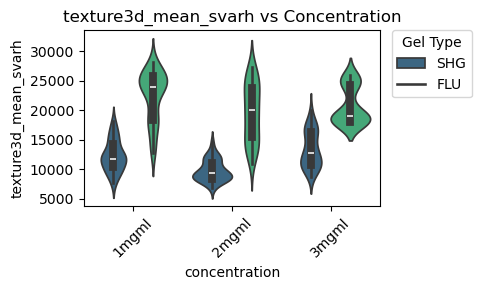

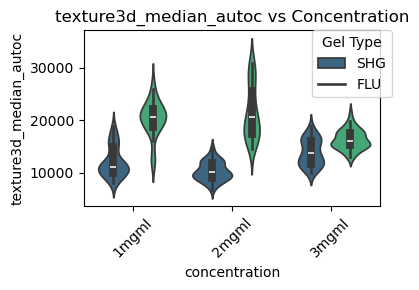

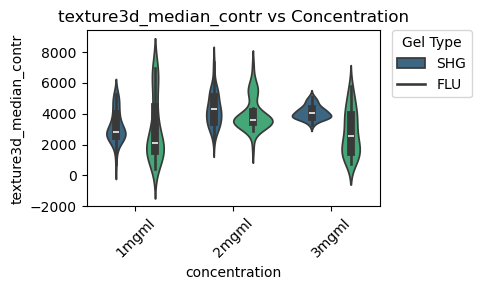

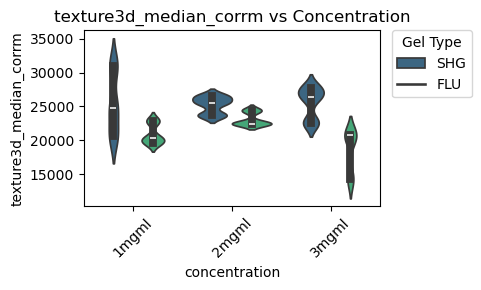

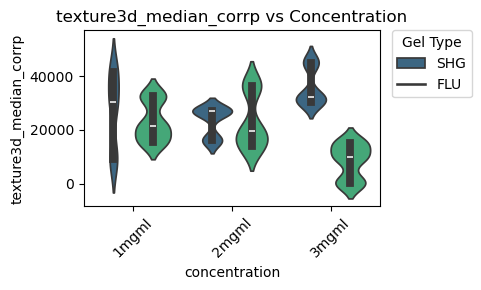

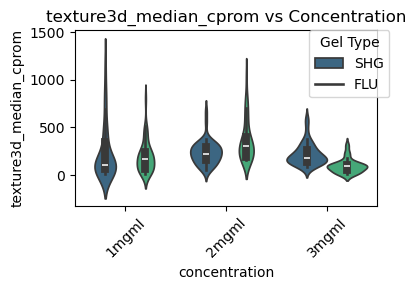

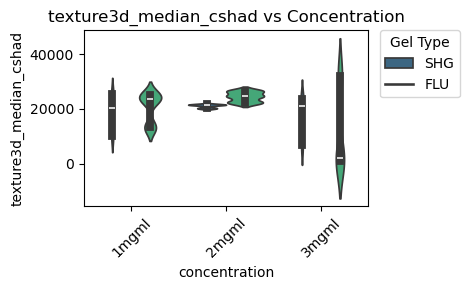

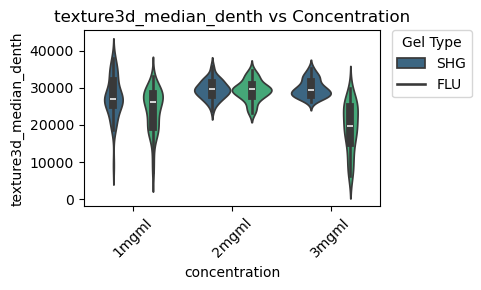

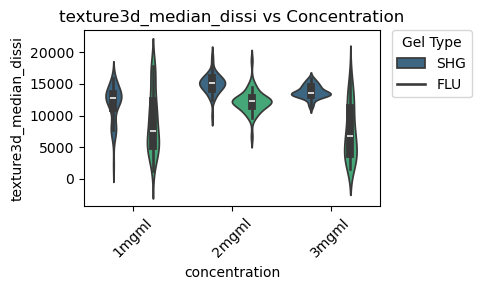

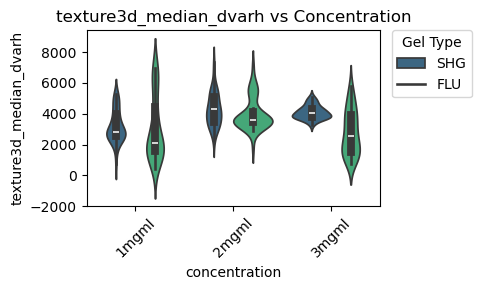

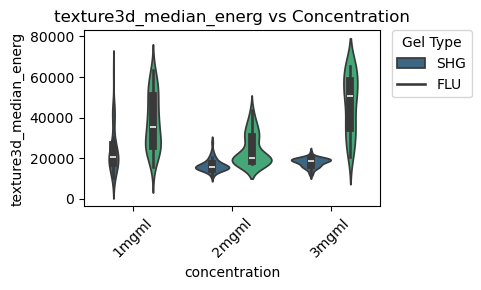

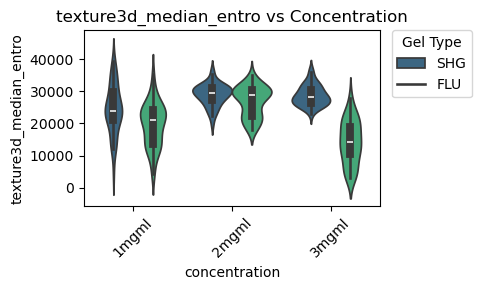

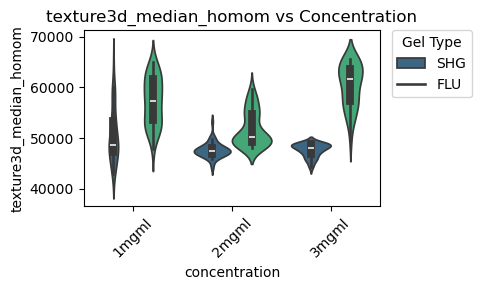

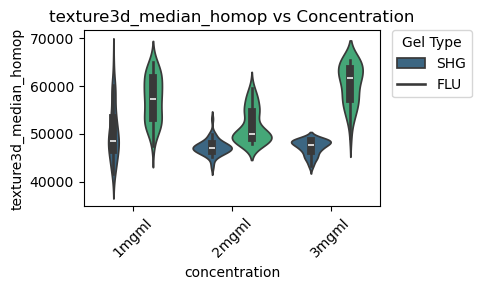

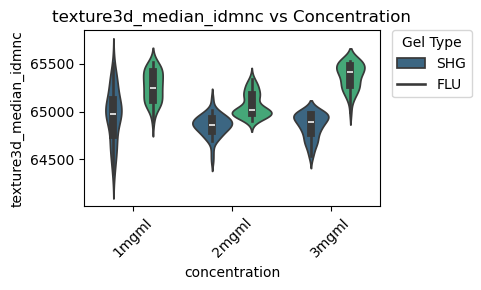

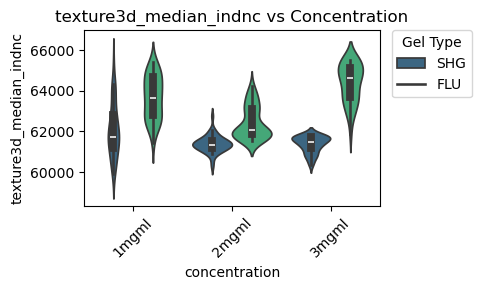

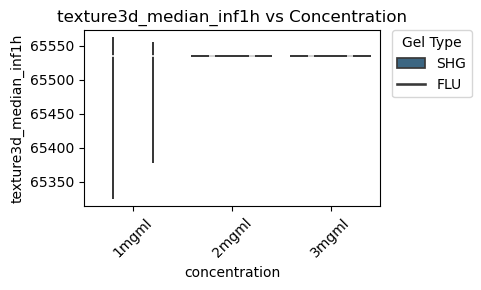

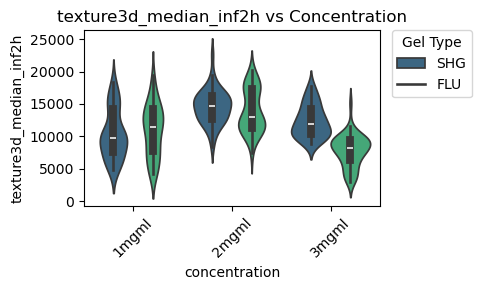

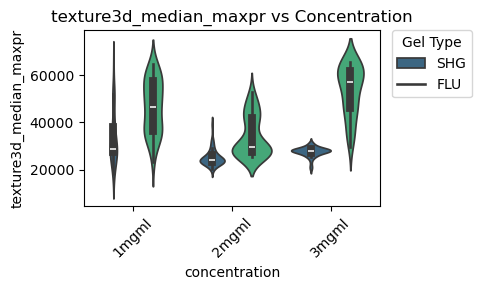

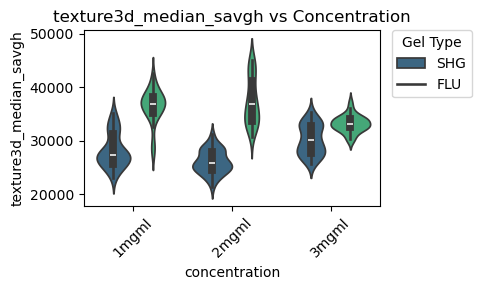

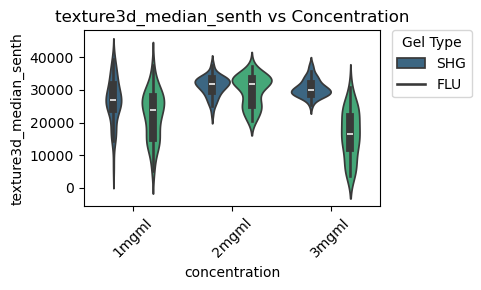

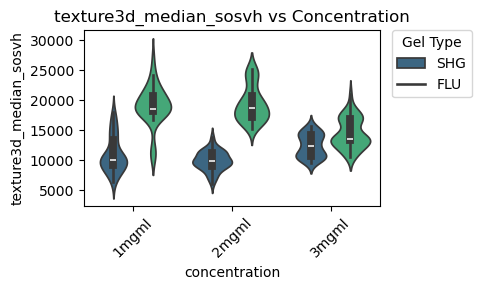

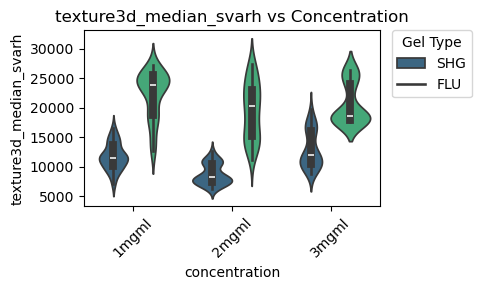

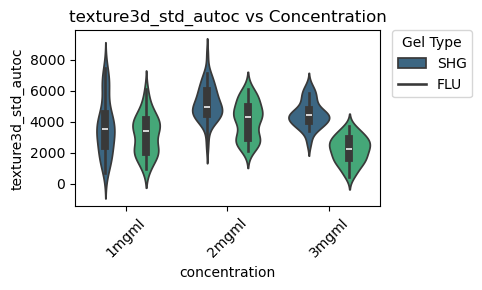

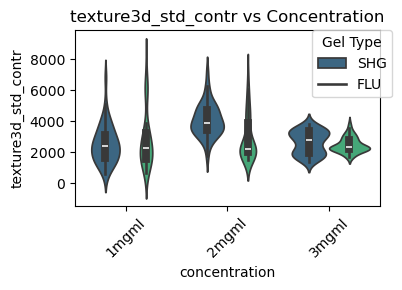

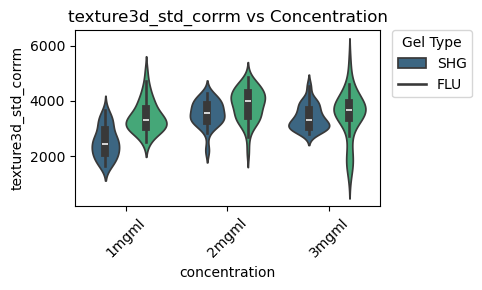

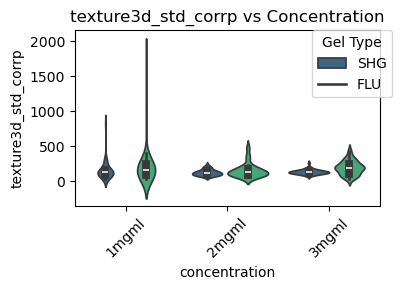

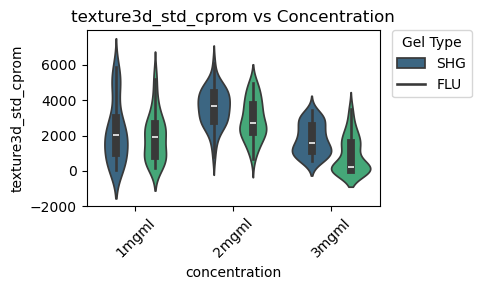

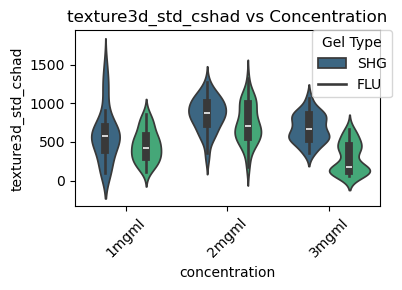

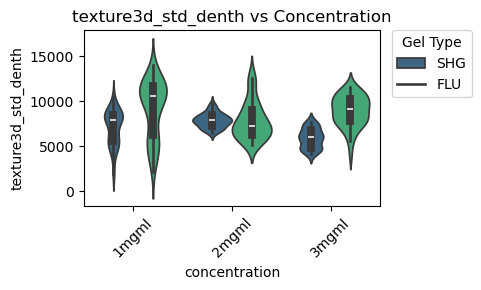

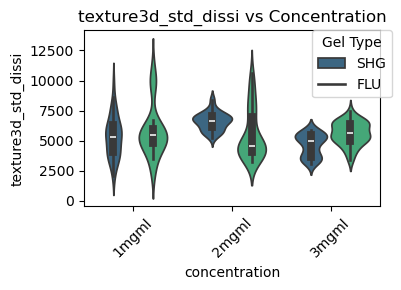

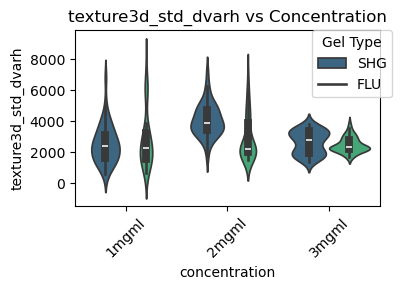

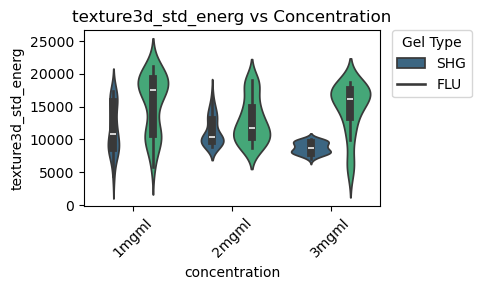

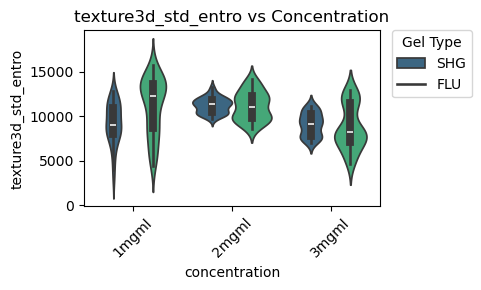

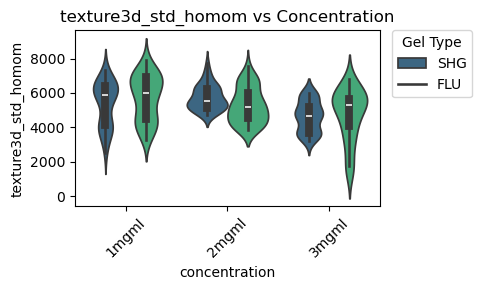

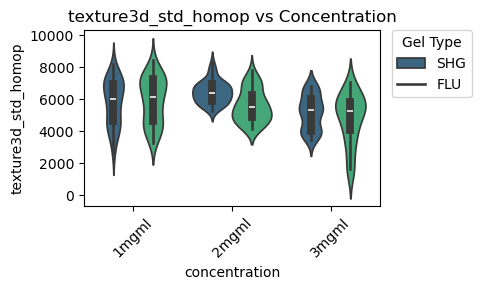

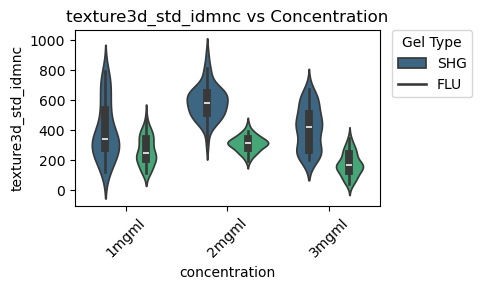

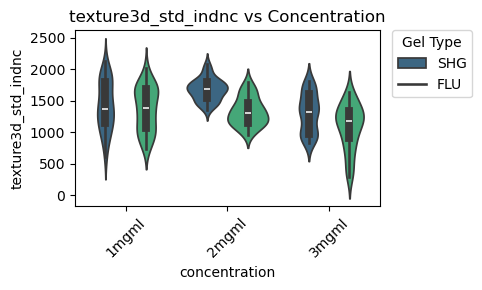

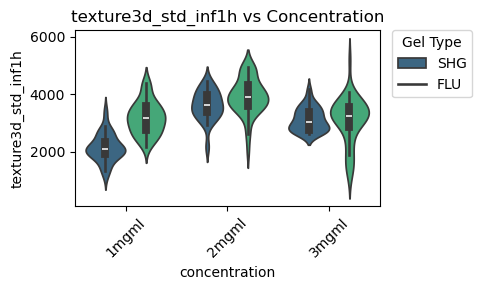

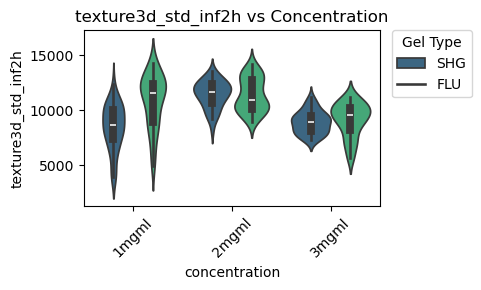

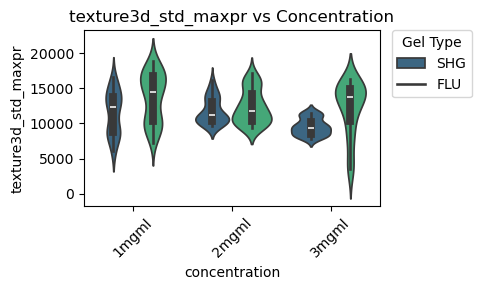

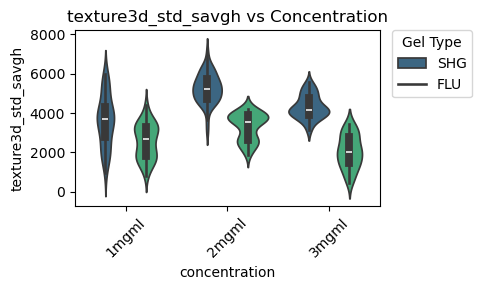

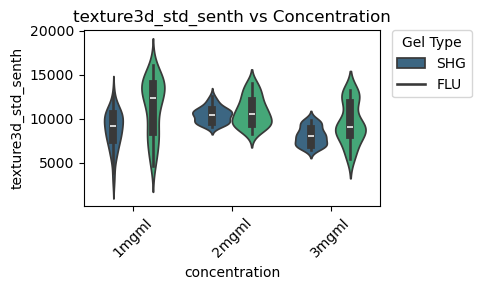

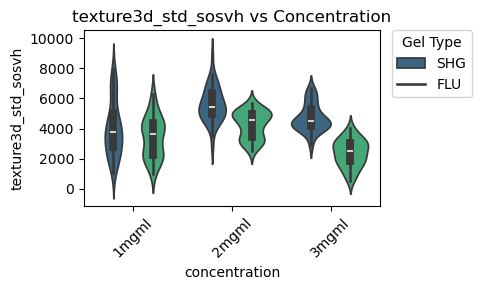

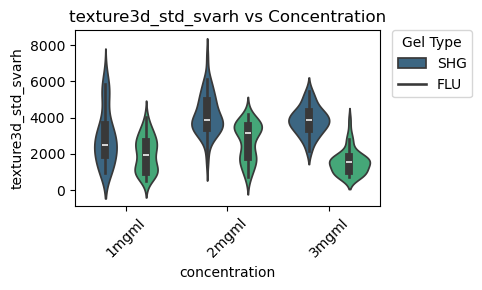

In [25]:
df["concentration"] = df["image_name"].str.extract(r"(\d+mgml)")
#sns.boxplot(data=df, x="concentration", y="total_fibers_HistLEN")

sns.boxplot(data=df, x="concentration", y="Total Length (microns)")

# Get all numeric columns except concentration and gel_type
numeric_cols = df.select_dtypes(include=[np.number]).columns
exclude_cols = ['concentration', 'gel_type', 'gel_concen', 'slice']
plot_cols = [col for col in numeric_cols if col not in exclude_cols]

# Create scatterplots for each column vs concentration, colored by gel_type
for col in plot_cols:
    plt.figure(figsize=(4, 3))
    sns.violinplot(data=df, x="concentration", y=col, hue="gel_type", palette="viridis")
    plt.title(f"{col} vs Concentration")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend(title="Gel Type", labels=["SHG", "FLU"], bbox_to_anchor=(1.04, 1), borderaxespad=0)
    plt.show()